In [7]:
import sys
import subprocess
try:
    import ultralytics
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", "ultralytics"])

import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

from pathlib import Path
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import yaml
from ultralytics import YOLO

KAGGLE = Path("/kaggle/input").exists()

if KAGGLE:
    candidates = list(Path("/kaggle/input").rglob("processed/images/train"))
    if not candidates:
        candidates = list(Path("/kaggle/input").rglob("images/train"))
    DATA_ROOT = candidates[0].parent.parent
    RUNS_DIR = Path("/kaggle/working/runs/yolov8")
    DEVICE = 0
    BATCH = 32
    EPOCHS = 30
else:
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent
    DATA_ROOT = PROJECT_ROOT / "data" / "processed"
    RUNS_DIR = PROJECT_ROOT / "runs" / "yolov8"
    DEVICE = "cpu"
    BATCH = 8
    EPOCHS = 20

RUNS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
IMG_SIZE = 640

DATA_YAML = RUNS_DIR / "data.yaml"
yaml_content = {
    "path": str(DATA_ROOT.resolve()),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {0: "cattle", 1: "sheep"},
}
with open(DATA_YAML, "w") as f:
    yaml.safe_dump(yaml_content, f, sort_keys=False)

print("kaggle:", KAGGLE)
print("data root:", DATA_ROOT)
print("runs dir:", RUNS_DIR)
print("device:", DEVICE)
print("batch:", BATCH, "epochs:", EPOCHS, "img:", IMG_SIZE)
print("data yaml:", DATA_YAML)


kaggle: True
data root: /kaggle/input/datasets/jazzyflavor/livestock-yolo-processed/processed
runs dir: /kaggle/working/runs/yolov8
device: 0
batch: 32 epochs: 30 img: 640
data yaml: /kaggle/working/runs/yolov8/data.yaml


In [8]:
best_pt = RUNS_DIR / "train" / "weights" / "best.pt"
if best_pt.exists():
    print(f"loading existing weights from {best_pt}")
    model = YOLO(str(best_pt))
    train_results = None
else:
    print("training yolov8n from scratch")
    model = YOLO("yolov8n.pt")
    t0 = time.time()
    train_results = model.train(
        data=str(DATA_YAML),
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH,
        patience=6,
        device=DEVICE,
        project=str(RUNS_DIR),
        name="train",
        seed=SEED,
        deterministic=True,
        verbose=True,
        plots=True,
        save=True,
        workers=2,
    )
    print(f"\ntrain time: {(time.time()-t0)/60:.1f} min")

print("model ready")


training yolov8n from scratch
Ultralytics 8.4.42 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/runs/yolov8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=aut

In [9]:
val_metrics = model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=DEVICE,
    project=str(RUNS_DIR),
    name="val_test",
    exist_ok=True,
    plots=True,
    verbose=True,
)

print("test detection metrics:")
print(f"  mAP@50:    {val_metrics.box.map50:.4f}")
print(f"  mAP@50-95: {val_metrics.box.map:.4f}")
print(f"  precision: {val_metrics.box.mp:.4f}")
print(f"  recall:    {val_metrics.box.mr:.4f}")
print()
print("per-class:")
for i, cls_name in enumerate(["cattle", "sheep"]):
    print(f"  {cls_name}: AP50={val_metrics.box.ap50[i]:.4f} AP50-95={val_metrics.box.ap[i]:.4f}")

detection_results = {
    "map50": float(val_metrics.box.map50),
    "map": float(val_metrics.box.map),
    "precision": float(val_metrics.box.mp),
    "recall": float(val_metrics.box.mr),
    "per_class": {
        "cattle": {"ap50": float(val_metrics.box.ap50[0]), "ap": float(val_metrics.box.ap[0])},
        "sheep":  {"ap50": float(val_metrics.box.ap50[1]), "ap": float(val_metrics.box.ap[1])},
    },
}


Ultralytics 8.4.42 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 16.6±8.4 MB/s, size: 129.6 KB)
val: Scanning /kaggle/input/datasets/jazzyflavor/livestock-yolo-processed/processed/labels/test... 1835 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1835/1835 153.4it/s 12.0s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/jazzyflavor/livestock-yolo-processed/processed/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 58/58 3.3it/s 17.5s0.3s
                   all       1835      31318      0.951      0.901      0.948      0.601
                cattle        995      11042      0.952      0.879      0.943      0.617
                 sheep        855      20276      0.951      0.924      0.953      0.585
Speed: 1.1ms preprocess, 3.7

In [15]:
import gc

test_imgs_dir = DATA_ROOT / "images" / "test"
test_lbls_dir = DATA_ROOT / "labels" / "test"

test_images = sorted([p for p in test_imgs_dir.glob("*") if p.suffix.lower() in (".jpg", ".jpeg", ".png")])
print(f"test images: {len(test_images)}")


def gt_count(img_path):
    lbl = test_lbls_dir / (img_path.stem + ".txt")
    if not lbl.exists():
        return 0
    return sum(1 for line in lbl.read_text().strip().splitlines() if line.strip())


gc.collect()
torch.cuda.empty_cache()
print(f"gpu mem before predict: {torch.cuda.memory_allocated()/1024**3:.2f} GiB allocated")

print("running inference one image at a time...")
t0 = time.time()

sample_indices = set(np.random.RandomState(SEED).choice(len(test_images), size=6, replace=False).tolist())
sample_results = {}
count_rows = []

for i, img_path in enumerate(test_images):
    r = model.predict(
        source=str(img_path),
        imgsz=416,
        device=DEVICE,
        conf=0.25,
        iou=0.45,
        verbose=False,
    )[0]
    gt = gt_count(img_path)
    pred = len(r.boxes) if r.boxes is not None else 0
    count_rows.append({
        "image_id": img_path.name,
        "gt_count": gt,
        "pred_count": pred,
    })
    if i in sample_indices:
        sample_results[i] = r.cpu()
    if i % 200 == 0 and i > 0:
        torch.cuda.empty_cache()
        elapsed = time.time() - t0
        print(f"  {i}/{len(test_images)} done, {elapsed:.0f}s")

print(f"inference time: {(time.time()-t0)/60:.1f} min")

count_df = pd.DataFrame(count_rows)
print()
print(count_df[["gt_count", "pred_count"]].describe())


test images: 1835
gpu mem before predict: 2.19 GiB allocated
running inference one image at a time...
  200/1835 done, 4s
  400/1835 done, 9s
  600/1835 done, 14s
  800/1835 done, 18s
  1000/1835 done, 22s
  1200/1835 done, 26s
  1400/1835 done, 30s
  1600/1835 done, 35s
  1800/1835 done, 39s
inference time: 0.7 min

          gt_count   pred_count
count  1835.000000  1835.000000
mean     17.067030    15.822343
std      20.334348    19.193869
min       1.000000     0.000000
25%       5.000000     4.000000
50%      11.000000    10.000000
75%      19.000000    19.000000
max     105.000000   101.000000


In [16]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

mae = mean_absolute_error(count_df["gt_count"], count_df["pred_count"])
mse = mean_squared_error(count_df["gt_count"], count_df["pred_count"])
rmse = np.sqrt(mse)
r2 = r2_score(count_df["gt_count"], count_df["pred_count"])
under_count = (count_df["pred_count"] < count_df["gt_count"]).sum()
over_count = (count_df["pred_count"] > count_df["gt_count"]).sum()
exact_match = (count_df["pred_count"] == count_df["gt_count"]).sum()

print("counting metrics on test split:")
print(f"  MAE:       {mae:.3f}")
print(f"  RMSE:      {rmse:.3f}")
print(f"  R^2:       {r2:.4f}")
print(f"  exact match: {exact_match} ({100*exact_match/len(count_df):.1f}%)")
print(f"  undercount:  {under_count} ({100*under_count/len(count_df):.1f}%)")
print(f"  overcount:   {over_count} ({100*over_count/len(count_df):.1f}%)")

counting_results = {
    "mae": float(mae),
    "rmse": float(rmse),
    "r2": float(r2),
    "exact_match_pct": float(100 * exact_match / len(count_df)),
    "undercount_pct": float(100 * under_count / len(count_df)),
    "overcount_pct": float(100 * over_count / len(count_df)),
    "n_test_images": int(len(count_df)),
}


counting metrics on test split:
  MAE:       1.576
  RMSE:      3.218
  R^2:       0.9749
  exact match: 857 (46.7%)
  undercount:  768 (41.9%)
  overcount:   210 (11.4%)


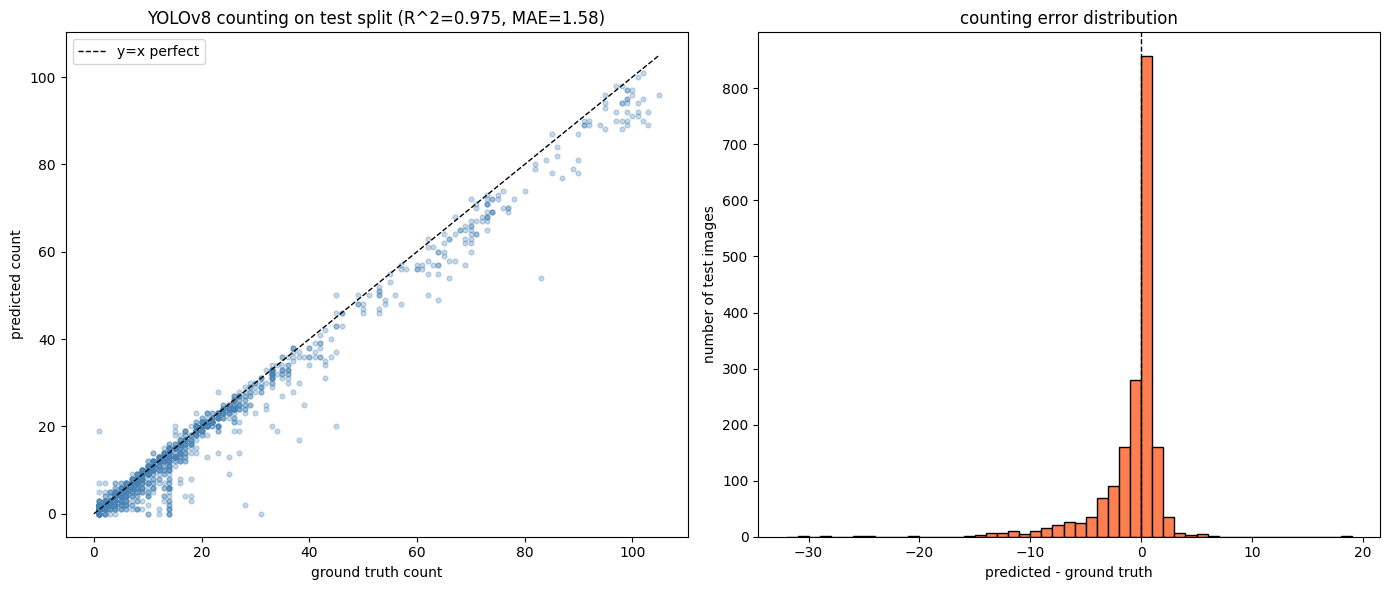

In [17]:
max_count = max(count_df["gt_count"].max(), count_df["pred_count"].max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(count_df["gt_count"], count_df["pred_count"], alpha=0.3, s=12, color="steelblue")
axes[0].plot([0, max_count], [0, max_count], "k--", linewidth=1, label="y=x perfect")
axes[0].set_xlabel("ground truth count")
axes[0].set_ylabel("predicted count")
axes[0].set_title(f"YOLOv8 counting on test split (R^2={r2:.3f}, MAE={mae:.2f})")
axes[0].legend()

errors = count_df["pred_count"] - count_df["gt_count"]
axes[1].hist(errors, bins=range(int(errors.min()) - 1, int(errors.max()) + 2), color="coral", edgecolor="black")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("predicted - ground truth")
axes[1].set_ylabel("number of test images")
axes[1].set_title("counting error distribution")

plt.tight_layout()
plt.savefig(RUNS_DIR / "counting_scatter.png", dpi=100, bbox_inches="tight")
plt.show()


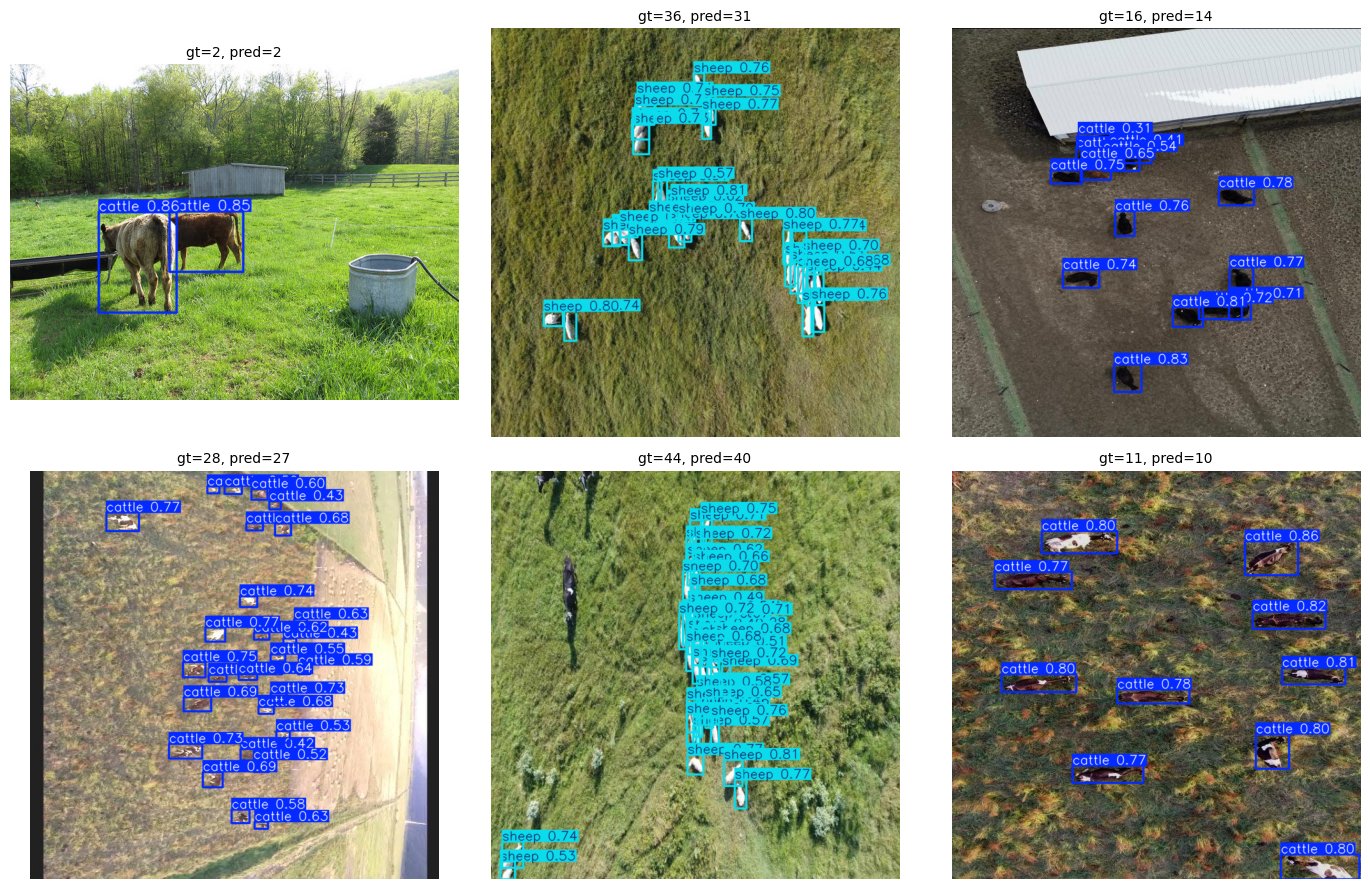

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()
for i, idx in enumerate(sorted(sample_indices)):
    r = sample_results[idx]
    plotted = r.plot()
    axes[i].imshow(plotted[..., ::-1])
    gt = count_df.iloc[idx]["gt_count"]
    pred = count_df.iloc[idx]["pred_count"]
    axes[i].set_title(f"gt={gt}, pred={pred}", fontsize=10)
    axes[i].axis("off")
plt.tight_layout()
plt.savefig(RUNS_DIR / "detection_samples.png", dpi=100, bbox_inches="tight")
plt.show()

In [20]:
all_results = {
    "model": "yolov8n",
    "img_size": IMG_SIZE,
    "epochs": EPOCHS,
    "batch": BATCH,
    "kaggle": KAGGLE,
    "detection": detection_results,
    "counting": counting_results,
}

with open(RUNS_DIR / "test_results.json", "w") as f:
    json.dump(all_results, f, indent=2)

count_df.to_csv(RUNS_DIR / "test_counts.csv", index=False)

print("yolov8 summary")
print()
print(f"detection mAP@50:    {detection_results['map50']:.4f}")
print(f"detection mAP@50-95: {detection_results['map']:.4f}")
print(f"counting MAE:        {counting_results['mae']:.3f}")
print(f"counting R^2:        {counting_results['r2']:.4f}")
print()
print(f"saved: {RUNS_DIR / 'test_results.json'}")
print(f"saved: {RUNS_DIR / 'test_counts.csv'}")
print()
print("artifacts:")
for p in sorted(RUNS_DIR.rglob("*")):
    if p.is_file():
        size = p.stat().st_size / 1024
        unit = "KB" if size < 1024 else "MB"
        if size >= 1024:
            size = size / 1024
        print(f"  {p.relative_to(RUNS_DIR)}: {size:.1f} {unit}")


yolov8 summary

detection mAP@50:    0.9478
detection mAP@50-95: 0.6007
counting MAE:        1.576
counting R^2:        0.9749

saved: /kaggle/working/runs/yolov8/test_results.json
saved: /kaggle/working/runs/yolov8/test_counts.csv

artifacts:
  counting_scatter.png: 79.4 KB
  data.yaml: 0.2 KB
  detection_samples.png: 2.1 MB
  test_counts.csv: 37.8 KB
  test_results.json: 0.7 KB
  train/BoxF1_curve.png: 139.3 KB
  train/BoxPR_curve.png: 108.6 KB
  train/BoxP_curve.png: 109.5 KB
  train/BoxR_curve.png: 138.0 KB
  train/args.yaml: 1.6 KB
  train/confusion_matrix.png: 131.2 KB
  train/confusion_matrix_normalized.png: 113.8 KB
  train/labels.jpg: 188.7 KB
  train/results.csv: 3.8 KB
  train/results.png: 287.0 KB
  train/train_batch0.jpg: 739.2 KB
  train/train_batch1.jpg: 709.8 KB
  train/train_batch2.jpg: 786.3 KB
  train/train_batch5360.jpg: 658.7 KB
  train/train_batch5361.jpg: 632.9 KB
  train/train_batch5362.jpg: 613.3 KB
  train/val_batch0_labels.jpg: 466.8 KB
  train/val_batch0_pre